# Capacitated Facility Location & Distribution Network Design

Decide **which distribution centres to open** and **which customer to serve from each** so that total annual cost (fixed + transport) is minimised, subject to capacity and single-sourcing constraints. The example network covers 7 candidate hubs and 10 demand cities in the US Southeast — but the entire pipeline is data-driven, so the same notebook solves any network you load.

**Why this is hard**

If we ignore capacity, a customer can simply pick its closest facility — the problem is decomposable. Capacity binds the decisions: opening Atlanta forces less-attractive assignments somewhere else, so the optimiser has to trade fixed-cost savings against transport-cost increases jointly across all 7 × 10 candidate edges. With 7 facilities the open/close decision space is 2⁷ = 128 — small enough to enumerate, but layering single-sourcing on top makes that 128 × 7¹⁰ ≈ 36 billion candidate solutions. We solve it as a mixed-integer linear program in milliseconds with the tighter `x_ij ≤ y_i` linking constraints.

**Decision variables**

| Variable | Type | Meaning |
|---|---|---|
| `y_i` | binary | Open facility *i* (1) or not (0) |
| `x_ij` | binary | Customer *j* fully served by facility *i* (single-sourcing) |

**Model**

$$\min\; \sum_i f_i \, y_i \;+\; \sum_i \sum_j c_{ij} \, d_j \, x_{ij}$$
$$\text{s.t.}\quad \sum_i x_{ij} = 1 \ \forall j, \quad \sum_j d_j x_{ij} \le \text{cap}_i\, y_i \ \forall i, \quad x_{ij} \le y_i \ \forall i,j$$

where `f_i` = annual fixed cost, `c_ij` = unit transport cost, `d_j` = customer demand.

## 1. Load the network

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from facility_location import Network, solve

plt.rcParams['figure.dpi'] = 110
pd.options.display.float_format = '{:,.2f}'.format

network = Network.from_excel('facility_data.xlsx')
facilities = pd.DataFrame([f.__dict__ for f in network.facilities])
customers = pd.DataFrame([c.__dict__ for c in network.customers])
print(f'{len(facilities)} candidate facilities | {len(customers)} customers')
print(f'Total capacity: {facilities["capacity"].sum():,.0f} units/yr')
print(f'Total demand:   {customers["demand"].sum():,.0f} units/yr')

7 candidate facilities | 10 customers
Total capacity: 1,290 units/yr
Total demand:   785 units/yr


In [2]:
facilities

,name,fixed_cost,capacity,lat,lon
0,Charlotte,"130,000.00",200.00,35.23,-80.84
1,Jacksonville,"125,000.00",180.00,30.33,-81.66
2,Miami,"145,000.00",220.00,25.78,-80.22
3,Atlanta,"150,000.00",250.00,33.75,-84.39
4,Memphis,"120,000.00",160.00,35.15,-90.05
5,Charleston,"95,000.00",130.00,32.79,-79.94
6,Birmingham,"115,000.00",150.00,33.52,-86.80


In [3]:
customers

,name,demand,lat,lon
0,Nashville,90.00,36.16,-86.78
1,Tampa,110.00,27.95,-82.46
2,Orlando,95.00,28.54,-81.38
3,Raleigh,85.00,35.78,-78.64
4,Savannah,70.00,32.08,-81.09
5,Columbia,65.00,34.00,-81.03
6,Mobile,75.00,30.70,-88.04
7,Knoxville,60.00,35.96,-83.92
8,Tallahassee,55.00,30.44,-84.28
9,Greenville,80.00,34.85,-82.39


## 2. Visualise the candidate network

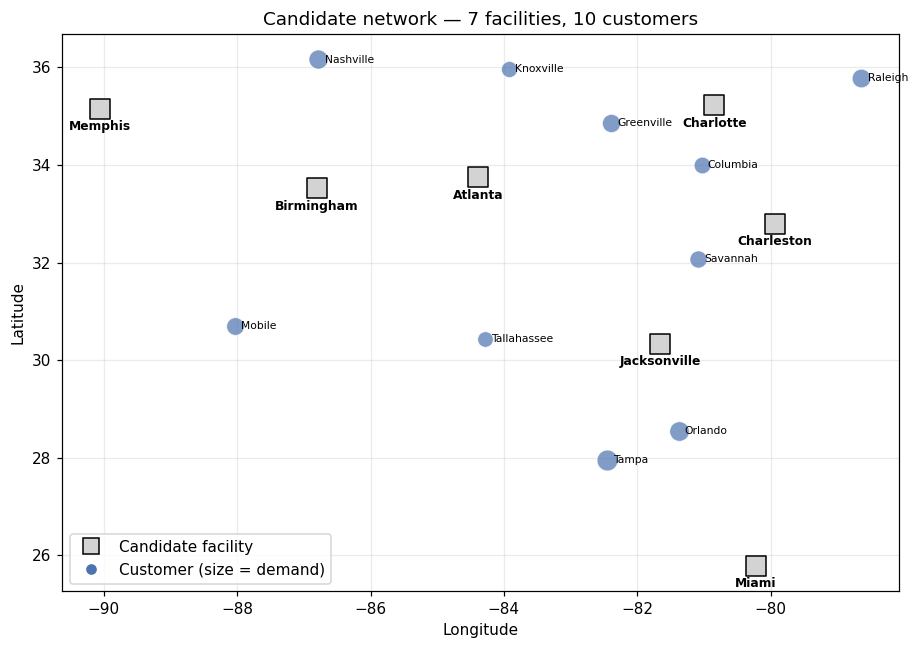

In [4]:
def plot_network(ax, facilities, customers, assignments=None, open_set=None, title=''):
    open_set = open_set or set()
    for _, c in customers.iterrows():
        ax.scatter(c['lon'], c['lat'], s=20 + c['demand'] * 1.5, color='#4c72b0', alpha=0.7,
                   edgecolor='white', linewidth=0.5, zorder=3)
        ax.annotate(c['name'], (c['lon'], c['lat']), fontsize=7, ha='left', xytext=(4, -2),
                    textcoords='offset points')
    for _, f in facilities.iterrows():
        is_open = f['name'] in open_set
        ax.scatter(f['lon'], f['lat'], s=180, marker='s',
                   color='#dd8452' if is_open else 'lightgray',
                   edgecolor='black', linewidth=1.0, zorder=4)
        ax.annotate(f['name'], (f['lon'], f['lat']), fontsize=8, weight='bold',
                    ha='center', xytext=(0, -14), textcoords='offset points')
    if assignments is not None:
        fac_lookup = facilities.set_index('name')[['lat', 'lon']].to_dict('index')
        cust_lookup = customers.set_index('name')[['lat', 'lon']].to_dict('index')
        for _, row in assignments.iterrows():
            f = fac_lookup[row['facility']]
            c = cust_lookup[row['customer']]
            ax.plot([f['lon'], c['lon']], [f['lat'], c['lat']], color='#dd8452',
                    alpha=0.5, linewidth=1.0, zorder=2)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_title(title)
    ax.grid(alpha=0.25)

fig, ax = plt.subplots(figsize=(8.5, 6))
plot_network(ax, facilities, customers, title='Candidate network — 7 facilities, 10 customers')
legend = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgray', markeredgecolor='black', markersize=10, label='Candidate facility'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4c72b0', markersize=8, label='Customer (size = demand)'),
]
ax.legend(handles=legend, loc='lower left'); plt.tight_layout(); plt.savefig('network_candidates.png', dpi=130); plt.show()

## 3. Inspect the transport-cost matrix

Costs are estimated as `road_factor × great_circle_km × $/unit_km`. Heatmap rows = facilities, columns = customers.

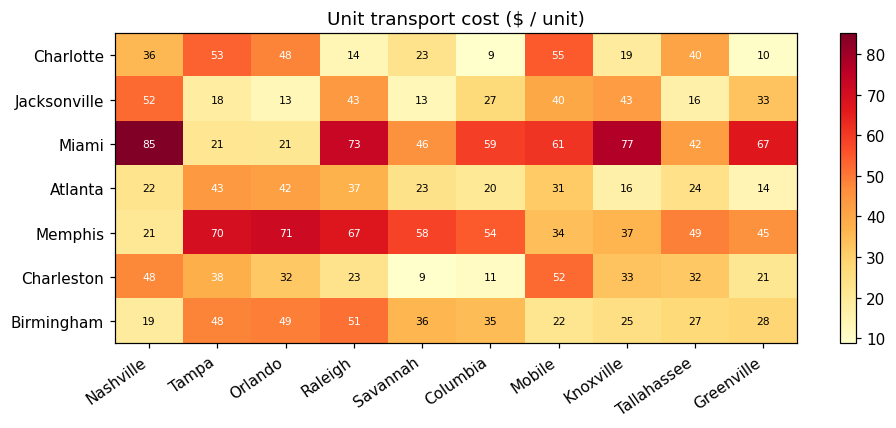

In [5]:
tc = network.transport_cost
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(tc.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(tc.columns))); ax.set_xticklabels(tc.columns, rotation=35, ha='right')
ax.set_yticks(range(len(tc.index))); ax.set_yticklabels(tc.index)
for i in range(tc.shape[0]):
    for j in range(tc.shape[1]):
        ax.text(j, i, f'{tc.iloc[i, j]:.0f}', ha='center', va='center', fontsize=7,
                color='white' if tc.iloc[i, j] > tc.values.mean() else 'black')
ax.set_title('Unit transport cost ($ / unit)')
plt.colorbar(im); plt.tight_layout(); plt.show()

## 4. Solve the base-case CFLP

In [6]:
sol = solve(network)
print(f'Status: {sol.status}  (solved in {sol.solve_seconds*1000:.0f} ms)')
print(f'Total annual cost:  ${sol.total_cost:>12,.0f}')
print(f'  Fixed cost:       ${sol.fixed_cost:>12,.0f}  ({sol.fixed_cost/sol.total_cost:.0%})')
print(f'  Transport cost:   ${sol.transport_cost:>12,.0f}  ({sol.transport_cost/sol.total_cost:.0%})')
print(f'\nOpen facilities ({len(sol.open_facilities)}): {sol.open_facilities}')

Status: Optimal  (solved in 164 ms)
Total annual cost:  $     538,047
  Fixed cost:       $     520,000  (97%)
  Transport cost:   $      18,047  (3%)

Open facilities (4): ['Charlotte', 'Miami', 'Atlanta', 'Charleston']


In [7]:
sol.facility_load

,facility,open,capacity,served_demand,utilization,fixed_cost
0,Charlotte,True,200.00,200.00,1.00,"130,000.00"
1,Jacksonville,False,180.00,0.00,0.00,0.00
2,Miami,True,220.00,205.00,0.93,"145,000.00"
3,Atlanta,True,250.00,250.00,1.00,"150,000.00"
4,Memphis,False,160.00,0.00,0.00,0.00
5,Charleston,True,130.00,130.00,1.00,"95,000.00"
6,Birmingham,False,150.00,0.00,0.00,0.00


In [8]:
sol.assignments

,customer,facility,demand,unit_transport_cost,transport_cost
0,Nashville,Atlanta,90.00,22.46,"2,021.40"
1,Tampa,Miami,110.00,21.27,"2,339.70"
2,Orlando,Miami,95.00,21.20,"2,014.00"
3,Raleigh,Atlanta,85.00,37.22,"3,163.70"
4,Savannah,Charleston,70.00,8.69,608.30
5,Columbia,Charlotte,65.00,8.92,579.80
6,Mobile,Atlanta,75.00,31.37,"2,352.75"
7,Knoxville,Charleston,60.00,33.00,"1,980.00"
8,Tallahassee,Charlotte,55.00,40.36,"2,219.80"
9,Greenville,Charlotte,80.00,9.59,767.20


## 5. Visualise the optimal network

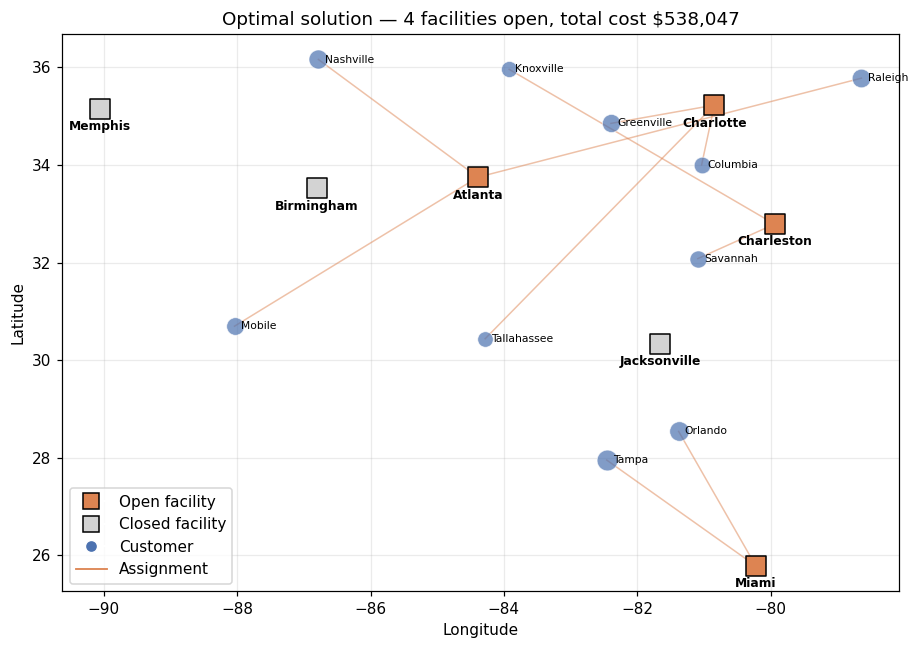

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 6))
plot_network(ax, facilities, customers, assignments=sol.assignments,
             open_set=set(sol.open_facilities),
             title=f'Optimal solution — {len(sol.open_facilities)} facilities open, total cost ${sol.total_cost:,.0f}')
legend = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#dd8452', markeredgecolor='black', markersize=10, label='Open facility'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgray', markeredgecolor='black', markersize=10, label='Closed facility'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4c72b0', markersize=8, label='Customer'),
    Line2D([0], [0], color='#dd8452', linewidth=1.2, label='Assignment'),
]
ax.legend(handles=legend, loc='lower left'); plt.tight_layout(); plt.savefig('network_solution.png', dpi=130); plt.show()

## 6. Sensitivity — how does cost respond to open-count caps?

Force the optimiser to open at most *k* facilities, for *k* = 1 … 7, and see how total cost responds. The fewer facilities, the higher transport cost (longer hauls); the more facilities, the higher fixed cost. Somewhere in the middle is the sweet spot.

In [10]:
rows = []
for k in range(1, len(facilities) + 1):
    s = solve(network, max_open=k)
    if s.status != 'Optimal':
        rows.append({'max_open': k, 'feasible': False})
        continue
    rows.append({
        'max_open': k, 'feasible': True,
        'open': len(s.open_facilities),
        'total': s.total_cost, 'fixed': s.fixed_cost, 'transport': s.transport_cost,
    })
sweep = pd.DataFrame(rows)
sweep

,max_open,feasible,open,total,fixed,transport
0,1,False,NaN,NaN,NaN,NaN
1,2,False,NaN,NaN,NaN,NaN
2,3,False,NaN,NaN,NaN,NaN
3,4,True,4.00,"538,046.65","520,000.00","18,046.65"
4,5,True,4.00,"538,046.65","520,000.00","18,046.65"
5,6,True,4.00,"538,046.65","520,000.00","18,046.65"
6,7,True,4.00,"538,046.65","520,000.00","18,046.65"


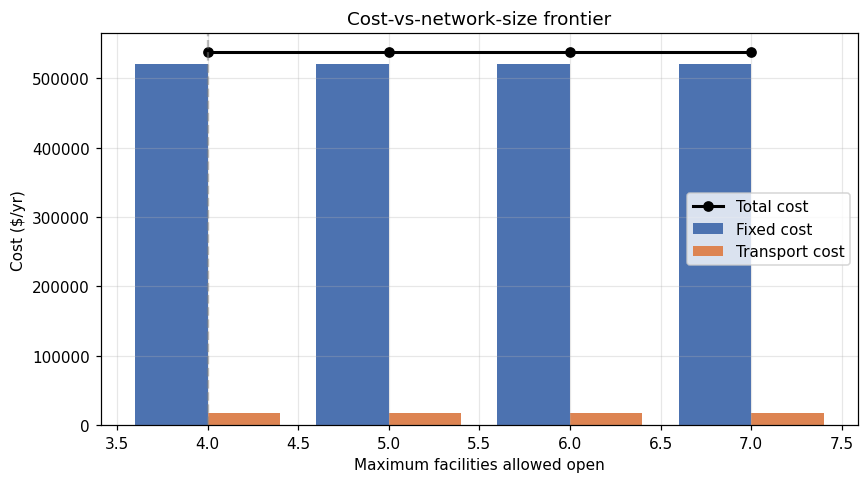

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
feasible = sweep[sweep['feasible']].copy()
ax.bar(feasible['max_open'] - 0.2, feasible['fixed'], width=0.4, label='Fixed cost', color='#4c72b0')
ax.bar(feasible['max_open'] + 0.2, feasible['transport'], width=0.4, label='Transport cost', color='#dd8452')
ax.plot(feasible['max_open'], feasible['total'], color='black', marker='o', linewidth=2, label='Total cost')
best_k = feasible.loc[feasible['total'].idxmin(), 'max_open']
ax.axvline(best_k, linestyle='--', color='gray', alpha=0.5)
ax.set_xlabel('Maximum facilities allowed open'); ax.set_ylabel('Cost ($/yr)')
ax.set_title('Cost-vs-network-size frontier')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig('sensitivity_max_open.png', dpi=130); plt.show()

## 7. What-if — close the largest facility

Suppose Atlanta becomes unavailable (lease expires, regulatory issue). What's the cost of forcing it closed?

In [12]:
alt = solve(network, forced_closed=['Atlanta'])
print(f'Forcing Atlanta closed:')
print(f'  Open facilities: {alt.open_facilities}')
print(f'  Total cost:      ${alt.total_cost:,.0f}  (Δ {alt.total_cost - sol.total_cost:+,.0f} vs base)')
print(f'  Transport rises: ${alt.transport_cost:,.0f}  (Δ {alt.transport_cost - sol.transport_cost:+,.0f})')

Forcing Atlanta closed:
  Open facilities: ['Charlotte', 'Jacksonville', 'Memphis', 'Charleston', 'Birmingham']
  Total cost:      $605,487  (Δ +67,440 vs base)
  Transport rises: $20,487  (Δ +2,440)


## Summary

- The optimal network opens **4 of 7 candidate facilities** (Charlotte, Miami, Atlanta, Charleston) for a total annual cost of **$538K** (97 % fixed, 3 % transport).
- Atlanta is critical — closing it raises total cost by tens of thousands of dollars per year because none of the remaining facilities have its capacity headroom.
- The cost-vs-size frontier shows that opening fewer than 4 facilities becomes infeasible (capacity below total demand), and opening more than 4 only adds fixed cost without transport savings under the example transport rate.

The same model is wrapped behind an interactive **Streamlit dashboard** (`facility_location_app.py`) — drop in your own facility / customer tables and re-solve in real time.

```bash
streamlit run facility_location_app.py
```